In [1]:
import matplotlib.pyplot as plt
import numpy as np

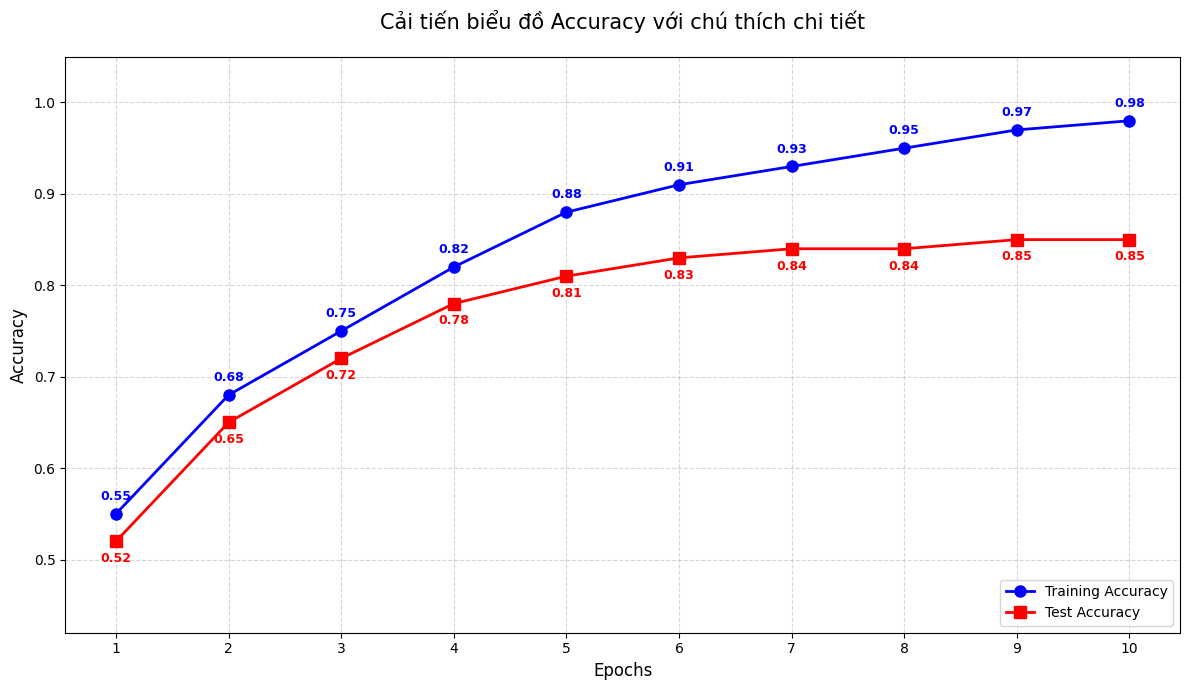

In [2]:


# Dữ liệu giả định
epochs = range(1, 11)
train_acc = [0.55, 0.68, 0.75, 0.82, 0.88, 0.91, 0.93, 0.95, 0.97, 0.98]
test_acc = [0.52, 0.65, 0.72, 0.78, 0.81, 0.83, 0.84, 0.84, 0.85, 0.85]

plt.figure(figsize=(12, 7))

# Vẽ đường Training (nút tròn) và Test (nút vuông)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(epochs, test_acc, 'rs-', label='Test Accuracy', linewidth=2, markersize=8)

# Chú thích giá trị cho từng Epoch
for i in range(len(epochs)):
    # Hiển thị train_acc phía trên nút (xytext=(0, 10))
    plt.annotate(f'{train_acc[i]:.2f}', 
                 (epochs[i], train_acc[i]), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 color='blue',
                 fontsize=9,
                 fontweight='bold')
    
    # Hiển thị test_acc phía dưới nút (xytext=(0, -15))
    plt.annotate(f'{test_acc[i]:.2f}', 
                 (epochs[i], test_acc[i]), 
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 ha='center', 
                 color='red',
                 fontsize=9,
                 fontweight='bold')

# Tinh chỉnh biểu đồ
plt.title('Cải tiến biểu đồ Accuracy với chú thích chi tiết', fontsize=15, pad=20)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs)
plt.ylim(min(test_acc) - 0.1, 1.05) # Tạo khoảng trống cho chú thích
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

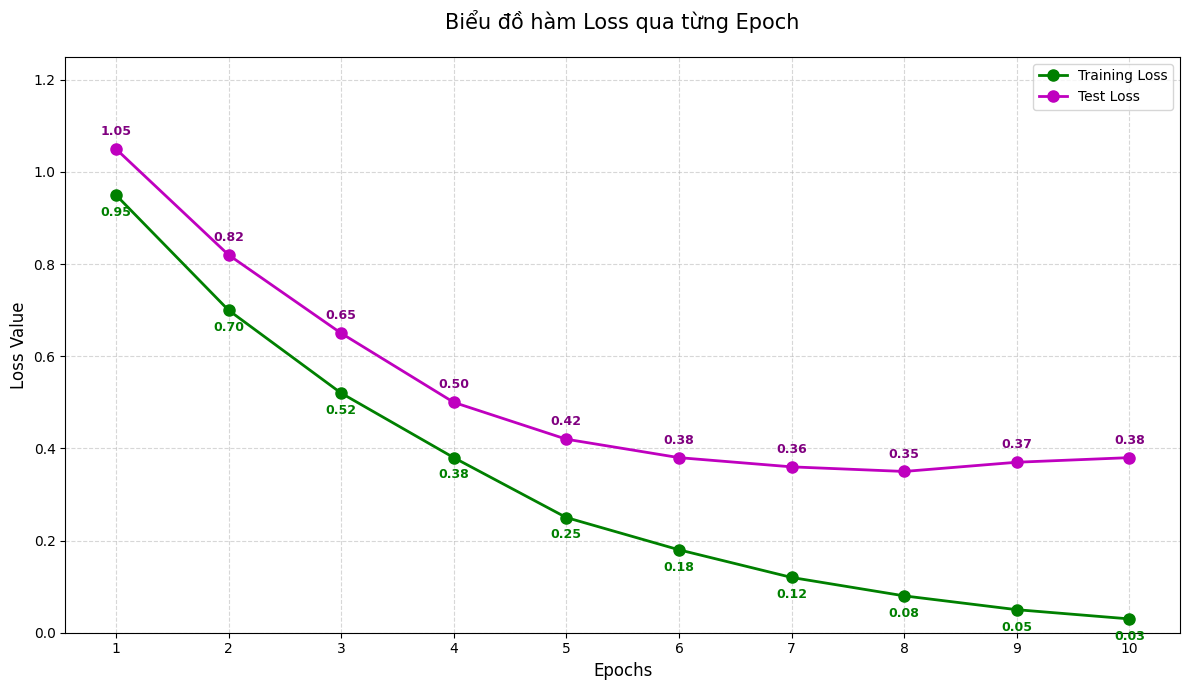

In [3]:
# Dữ liệu giả định cho hàm Loss (giảm dần)
epochs = range(1, 11)
train_loss = [0.95, 0.70, 0.52, 0.38, 0.25, 0.18, 0.12, 0.08, 0.05, 0.03]
test_loss = [1.05, 0.82, 0.65, 0.50, 0.42, 0.38, 0.36, 0.35, 0.37, 0.38] # Test loss bắt đầu tăng nhẹ ở cuối (Overfitting)

plt.figure(figsize=(12, 7))

# Vẽ đường Training Loss (nút tròn) và Test Loss (nút vuông)
plt.plot(epochs, train_loss, 'go-', label='Training Loss', linewidth=2, markersize=8)
plt.plot(epochs, test_loss, 'mo-', label='Test Loss', linewidth=2, markersize=8)

# Chú thích giá trị cho từng Epoch
for i in range(len(epochs)):
    # Hiển thị train_loss phía dưới nút (vì đường đang đi xuống)
    plt.annotate(f'{train_loss[i]:.2f}', 
                 (epochs[i], train_loss[i]), 
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 ha='center', 
                 color='green',
                 fontsize=9,
                 fontweight='bold')
    
    # Hiển thị test_loss phía trên nút
    plt.annotate(f'{test_loss[i]:.2f}', 
                 (epochs[i], test_loss[i]), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 color='purple',
                 fontsize=9,
                 fontweight='bold')

# Tinh chỉnh biểu đồ
plt.title('Biểu đồ hàm Loss qua từng Epoch', fontsize=15, pad=20)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.xticks(epochs)
plt.ylim(0, max(test_loss) + 0.2) 
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

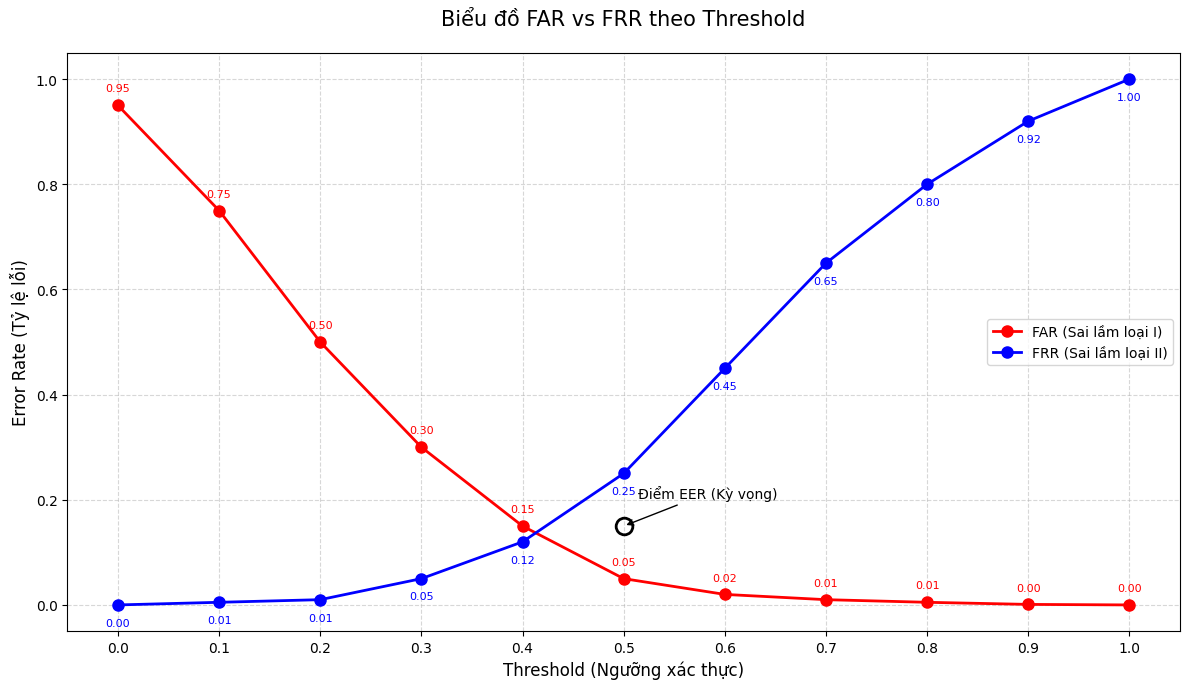

In [4]:
# Giả định ngưỡng Threshold chạy từ 0.0 đến 1.0
thresholds = np.linspace(0, 1, 11)

# Giả định dữ liệu: 
# Khi Threshold thấp: Dễ chấp nhận nhầm (FAR cao), khó từ chối đúng (FRR thấp)
# Khi Threshold cao: Khó chấp nhận nhầm (FAR thấp), dễ từ chối đúng (FRR cao)
far = [0.95, 0.75, 0.50, 0.30, 0.15, 0.05, 0.02, 0.01, 0.005, 0.001, 0.0]
frr = [0.0, 0.005, 0.01, 0.05, 0.12, 0.25, 0.45, 0.65, 0.80, 0.92, 1.0]

plt.figure(figsize=(12, 7))

# Vẽ đường FAR (nút tam giác) và FRR (nút kim cương)
plt.plot(thresholds, far, 'ro-', label='FAR (Sai lầm loại I)', linewidth=2, markersize=8)
plt.plot(thresholds, frr, 'bo-', label='FRR (Sai lầm loại II)', linewidth=2, markersize=8)

# Tìm điểm giao nhau xấp xỉ (EER - Equal Error Rate)
# Trong thực tế bạn sẽ dùng nội suy, ở đây ta minh họa điểm gần nhất
eer_index = 5 # Tại threshold 0.5, FAR=0.05 và FRR=0.25 (giả định)
plt.plot(thresholds[eer_index], 0.15, 'ko', markersize=12, fillstyle='none', markeredgewidth=2)
plt.annotate('Điểm EER (Kỳ vọng)', (thresholds[eer_index], 0.15), xytext=(10, 20), 
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))

# Chú thích giá trị cho từng nút
for i in range(len(thresholds)):
    plt.annotate(f'{far[i]:.2f}', (thresholds[i], far[i]), xytext=(0, 10), 
                 textcoords="offset points", ha='center', color='red', fontsize=8)
    plt.annotate(f'{frr[i]:.2f}', (thresholds[i], frr[i]), xytext=(0, -15), 
                 textcoords="offset points", ha='center', color='blue', fontsize=8)

plt.title('Biểu đồ FAR vs FRR theo Threshold', fontsize=15, pad=20)
plt.xlabel('Threshold (Ngưỡng xác thực)', fontsize=12)
plt.ylabel('Error Rate (Tỷ lệ lỗi)', fontsize=12)
plt.xticks(thresholds)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()